### **Importing Libraries**

In [1]:
import os
from pathlib import Path
import pywt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne.io import Raw
from mne import Epochs, find_events, pick_types
from mne.filter import filter_data
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac


# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Epochs Data**

In [2]:
# Directory where preprocessed `.fif` files are stored
SAVE_DIR = "processed_epochs"  # Update to your save directory

def load_epochs(subject_id, save_dir=SAVE_DIR):
    """
    Load all `.fif` files for a specific subject.

    Parameters:
    - subject_id: The subject identifier (e.g., 'sub-01').
    - save_dir: The base directory containing processed `.fif` files.

    Returns:
    - epochs_list: List of mne.Epochs objects for the subject.
    """
    subject_path = Path(save_dir) / subject_id
    if not subject_path.exists():
        raise FileNotFoundError(f"Directory for {subject_id} not found in {save_dir}!")

    # Find all `.fif` files in the subject's directory
    fif_files = sorted(subject_path.glob("*_processed-epo.fif"))
    if not fif_files:
        raise FileNotFoundError(f"No `.fif` files found for {subject_id} in {subject_path}.")

    # Load each `.fif` file into an mne.Epochs object
    epochs_list = [mne.read_epochs(str(f), preload=True) for f in fif_files]
    print(f"Loaded {len(epochs_list)} `.fif` files for {subject_id}.")
    return epochs_list


In [3]:
# Example usage
subject_id = "sub-01"  # Replace with the subject ID you want to load
epochs_01 = load_epochs(subject_id)



Loaded 3 `.fif` files for sub-01.


In [4]:
sfreq = 1000.0

### **Extracting Events**

In [5]:

def get_events_from_epochs(epochs):
    """
    Retrieve events and event IDs from an mne.Epochs object.
    
    Parameters:
    - epochs: An mne.Epochs object.
    
    Returns:
    - events: The events array (shape: n_events x 3).
    - event_id: A dictionary mapping event names to event IDs.
    """
    events = epochs.events  # Shape: (n_events, 3)
    event_id = epochs.event_id  # Dictionary: {event_name: event_code}
    return events, event_id

# Retrieve events for each epochs file
for i, epochs in enumerate(epochs_01):
    print(f"File {i + 1}:")
    events, event_id = get_events_from_epochs(epochs)
    print(f"  Events shape: {events.shape}")
    print(f"  Event IDs: {event_id}")


File 1:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 2:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 3:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}


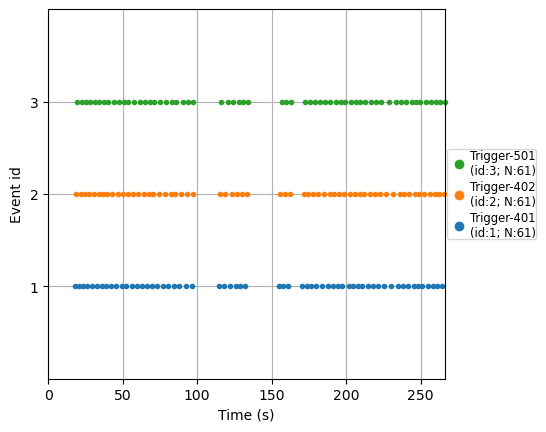

In [6]:
# Extract events 

fig = mne.viz.plot_events(events, sfreq=sfreq, event_id=event_id);

### **Electrode positions**

In [7]:
# Load electrode metadata
electrodes_tsv = 'ds005545-download/sub-80/ses-01/ieeg/sub-80_ses-01_electrodes.tsv'
electrode_positions = pd.read_csv(electrodes_tsv, sep='\t')

# Display electrode positions
print(electrode_positions.head())

  name          x          y          z  size
0   A3 -50.106579 -58.395985  23.277752     0
1   A4 -59.254402 -54.785877  15.215353     0
2   A5 -59.978233 -40.066578  39.257343     0
3   A6 -45.325970 -28.038254  37.129173     0
4   A7 -54.598400 -25.692129  44.675392     0


In [8]:
# Epochs_data is a 3D array of dimension (239 epochs, 306 channels, 106 time instants).
epochs_data = epochs.get_data()
type(epochs_data), epochs_data.shape

(numpy.ndarray, (183, 58, 701))

C:\Users\lacom\AppData\Local\Temp\ipykernel_2864\420767304.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')


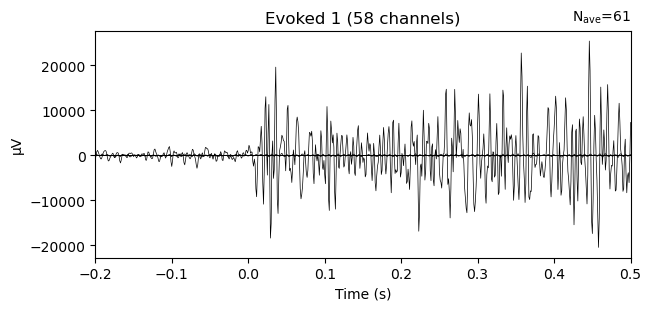

C:\Users\lacom\AppData\Local\Temp\ipykernel_2864\420767304.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')


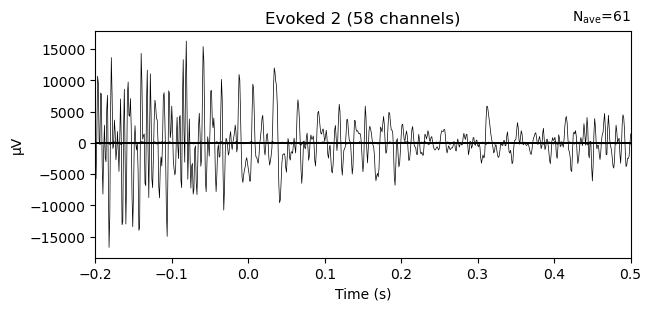

In [9]:
# Accessing and indexing epochs by condition
evoked_1 = epochs['Trigger-401'].average()
evoked_2 = epochs['Trigger-402'].average()

fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')
fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')

### Power Spectral Density (PSD)

In [13]:
print(f"  Event IDs: {event_id}")

  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}


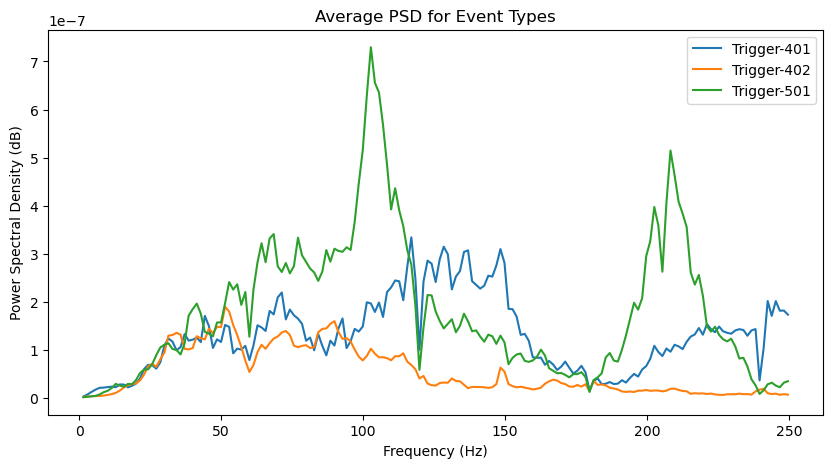

In [ ]:
event1 = 'Trigger-401'
event2 = 'Trigger-402'
event3 = 'Trigger-501'


# Separate epochs for each event type
epochs_event1 = epochs[event1]
epochs_event2 = epochs[event2]
epochs_event3 = epochs[event3]

# Compute PSD for each event type
def compute_psd(epochs, sfreq, fmin=1, fmax=250):
    data = epochs.get_data()
    psd, freqs = [], None
    for ep in data:
        n_times = ep.shape[-1]
        n_fft = min(2048, n_times)
        psd_epoch, freqs = psd_array_welch(ep, sfreq=sfreq, fmin=1, fmax=fmax, n_fft=n_fft, n_overlap=n_fft // 2)
        psd.append(psd_epoch)
    return np.array(psd), freqs

sfreq = epochs.info['sfreq']

psd_event1, freqs = compute_psd(epochs_event1, sfreq)
psd_event2, freqs = compute_psd(epochs_event2, sfreq)
psd_event3, freqs = compute_psd(epochs_event3, sfreq)


# Plot PSD comparison
plt.figure(figsize=(10, 5))
plt.plot(freqs, psd_event1.mean(axis=(0, 1)), label=event1)
plt.plot(freqs, psd_event2.mean(axis=(0, 1)), label=event2)
plt.plot(freqs, psd_event3.mean(axis=(0, 1)), label=event3)
plt.title("Average PSD for Event Types")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend()
plt.show()

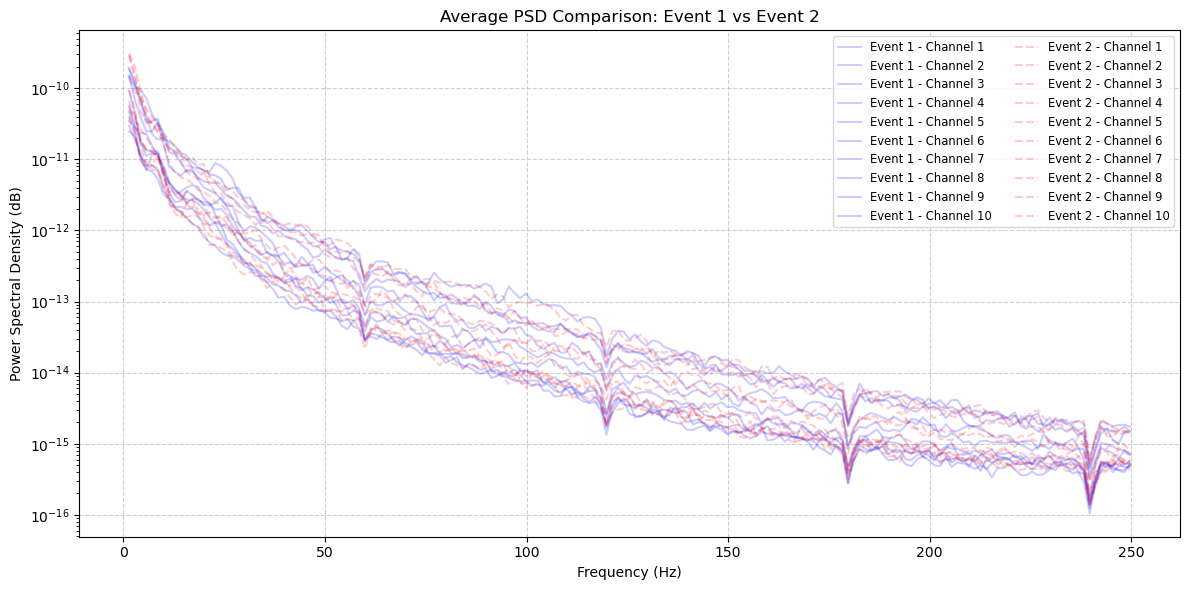

In [23]:
# Average PSD across epochs for both events
avg_psd_event1 = psd_event1.mean(axis=0)  # Shape: (n_channels, n_freqs)
avg_psd_event2 = psd_event2.mean(axis=0)  # Shape: (n_channels, n_freqs)
avg_psd_event3 = psd_event3.mean(axis=0)  # Shape: (n_channels, n_freqs)

# Visualization of Average PSD for Event 1 and Event 2
plt.figure(figsize=(12, 6))

# Plot Event 1
for ch_idx, ch_psd in enumerate(avg_psd_event1):
    if ch_idx < 10:  # Plot only the first 5 channels to avoid clutter
        plt.plot(freqs, ch_psd, label=f"Event 1 - Channel {ch_idx+1}", color='blue', alpha=0.2)

# Plot Event 2
for ch_idx, ch_psd in enumerate(avg_psd_event2):
    if ch_idx < 10:  # Plot only the first 5 channels
        plt.plot(freqs, ch_psd, label=f"Event 2 - Channel {ch_idx+1}", color='red', linestyle="--", alpha=0.2)



# Optional: Add a log scale for the y-axis
plt.yscale("log")

# Plot labels and legend
plt.title("Average PSD Comparison: Event 1 vs Event 2")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend(loc="upper right", ncol=2, fontsize="small")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

In [25]:
# --- Frequency Band Analysis ---
# Define frequency bands
bands = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 40),
}

# Helper function to compute average PSD for frequency bands
def compute_band_psd(avg_psd, freqs, bands, ch_names):
    """Calculate mean PSD for defined frequency bands."""
    band_psd_df = pd.DataFrame(index=ch_names)
    for band, (fmin, fmax) in bands.items():
        band_indices = np.where((freqs >= fmin) & (freqs < fmax))[0]  # Indices of frequencies in this band
        band_psd_df[band] = avg_psd[:, band_indices].mean(axis=1)  # Average PSD across band frequencies
    band_psd_df.index.name = "Electrode"
    return band_psd_df

# Compute Band PSD for Event 1 and Event 2
band_psd_event1 = compute_band_psd(psd_event1.mean(axis=0), freqs, bands, epochs_event1.ch_names)
band_psd_event2 = compute_band_psd(psd_event2.mean(axis=0), freqs, bands, epochs_event2.ch_names)
band_psd_event3 = compute_band_psd(psd_event3.mean(axis=0), freqs, bands, epochs_event2.ch_names)


# Print Frequency Band PSD DataFrames for both events

band_psd_event1.head()


,Delta,Theta,Alpha,Beta,Gamma
Electrode,,,,,
POL B1-B2,1.530653e-10,4.329015e-11,1.805173e-11,6.619096e-12,1.527449e-12
POL B17-B18,3.111453e-11,8.009430e-12,3.325109e-12,8.198202e-13,1.918590e-13
POL B25-B26,2.290712e-11,9.326678e-12,3.969015e-12,1.244850e-12,2.265173e-13
POL B33-B34,1.285589e-10,7.020337e-11,2.093589e-11,7.170098e-12,1.625714e-12
POL B2-B3,1.551450e-10,4.566469e-11,2.058797e-11,4.691799e-12,1.161620e-12


In [26]:
# Initialize an empty list to collect reshaped data
reshaped_data = []

# Loop through events (Event 1 and Event 2)
for event_id, band_psd_df in enumerate([band_psd_event1, band_psd_event2], start=1):
    # Add a column for the event type (Event 1 or Event 2)
    band_psd_df["Event"] = event_id

    # Convert the DataFrame into a long format (one row per electrode and frequency band)
    long_format = band_psd_df.reset_index().melt(
        id_vars=["Electrode", "Event"],
        var_name="Frequency Band",
        value_name="Power"
    )

    # Create a column combining "Electrode" and "Frequency Band" as the feature
    long_format["Feature"] = long_format["Electrode"] + " x " + long_format["Frequency Band"]

    # Pivot to a wide format where each feature (electrode x frequency band) becomes a column
    wide_format = long_format.pivot_table(
        index="Event",  # Use Event as the index
        columns="Feature",  # Columns for each electrode x frequency band feature
        values="Power"  # Values for the features
    )

    # Since you only have one subject, manually add the Subject ID
    wide_format["Subject"] = 1  # Single subject, so subject ID is 1

    # Reset index to make the DataFrame flat
    reshaped_data.append(wide_format.reset_index(drop=True))

# Concatenate data for both events
final_reshaped_df = pd.concat(reshaped_data, ignore_index=True)

# Add the Event column manually after concatenation
final_reshaped_df["Event"] = np.repeat([1, 2], [1, 1])  # Event 1 and Event 2 (both with one subject)

# Reorder columns: Subject, all features, Event
columns = ["Subject"] + [col for col in final_reshaped_df.columns if col not in ["Subject", "Event"]] + ["Event"]
final_reshaped_df = final_reshaped_df[columns]

# Display the final DataFrame
final_reshaped_df.head()

Feature,Subject,POL B1-B2 x Alpha,POL B1-B2 x Beta,POL B1-B2 x Delta,POL B1-B2 x Gamma,POL B1-B2 x Theta,POL B1-B9 x Alpha,POL B1-B9 x Beta,POL B1-B9 x Delta,POL B1-B9 x Gamma,...,POL DC01 x Beta,POL DC01 x Delta,POL DC01 x Gamma,POL DC01 x Theta,POL DC02 x Alpha,POL DC02 x Beta,POL DC02 x Delta,POL DC02 x Gamma,POL DC02 x Theta,Event
0,1,1.805173e-11,6.619096e-12,1.530653e-10,1.527449e-12,4.329015e-11,1.394438e-11,3.994396e-12,9.356037e-11,8.259656e-13,...,0.000003,2.555469e-07,0.000007,9.515756e-07,2.176097e-09,1.966103e-09,1.738383e-09,1.586761e-09,1.802105e-09,1
1,1,2.021106e-11,6.266578e-12,2.575440e-10,1.528844e-12,5.576681e-11,1.314835e-11,3.447082e-12,1.532910e-10,6.858264e-13,...,0.000003,1.027270e-07,0.000007,1.955599e-07,2.369006e-09,2.120469e-09,1.678894e-09,1.666454e-09,1.928184e-09,2


### Machine Learning

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from mne.decoding import SlidingEstimator, cross_val_multiscore

In [14]:
#To keep chance level at 50% accuracy, we first equalize the number of epochs in each condition.
epochs.equalize_event_counts(event_id)

# Separate auditory and visual epochs
Trigger1_epochs = epochs['Trigger-401']
Trigger2_epochs = epochs['Trigger-402']

# Print information about the equalized epochs
print(Trigger1_epochs)
print(Trigger2_epochs)

<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~19.0 MiB, data loaded,
 'Trigger-401': 61>
<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~19.0 MiB, data loaded,
 'Trigger-402': 61>


In [15]:

def preprocess_epochs_to_dataframe(epochs, event_id, event_conditions, pick_eeg=True):
    """
    Preprocess EEG epochs data into a flattened DataFrame with channel-timepoint features and labels.
    
    Parameters:
    - epochs: The Epochs object containing EEG data (mne.Epochs).
    - event_id: A dictionary mapping event names to event IDs (e.g., {'auditory/left': 1, 'visual/right': 2}).
    - event_conditions: A list of event conditions to consider for labeling (e.g., ['auditory/left', 'visual/right']).
    - pick_eeg: Whether to select only EEG channels (default is True).
    
    Returns:
    - X_df: A pandas DataFrame with flattened EEG data and corresponding labels.
    """
    
    # Step 1: Select only EEG channels if specified
    if pick_eeg:
        epochs = epochs.pick_types(eeg=True)
    
    # Get the data (shape: [n_epochs, n_channels, n_timepoints])
    X = epochs.get_data()  # Shape: (n_epochs, n_channels, n_timepoints)
    
    # Step 2: Create feature names (channel-timepoint pairs)
    feature_names = []
    n_channels = X.shape[1]
    n_timepoints = X.shape[2]

    for ch in range(n_channels):  # Iterate over EEG channels
        for t in range(n_timepoints):  # Iterate over time points
            feature_names.append(f"Channel_{ch}_Time_{t}")
    
    # Step 3: Flatten the data (preserving channel-timepoint structure)
    X_flattened = X.reshape(X.shape[0], -1)  # Shape: (n_epochs, n_channels * n_timepoints)

    # Step 4: Initialize the label array
    y = np.empty(len(epochs.events), dtype=int)
    
    # Step 5: Assign labels based on event conditions
    for condition in event_conditions:
        idx_condition = epochs.events[:, 2] == event_id[condition]
        y[idx_condition] = event_conditions.index(condition)  # Assign labels based on condition order
    
    # Step 6: Create a DataFrame with flattened data and feature names
    X_df = pd.DataFrame(X_flattened, columns=feature_names)
    
    # Step 7: Add the labels to the DataFrame (optional)
    X_df['label'] = y
    
    # Step 8: Return the DataFrame with features and labels
    return X_df



In [16]:
# Define the event conditions you want to label
event_conditions = ['Trigger-401', 'Trigger-402', 'Trigger-501'] 
# Assuming 'epochs' is your MNE Epochs object
X_df = preprocess_epochs_to_dataframe(epochs, event_id, event_conditions)

# Check the first few rows of the resulting DataFrame
X_df.head()

,Channel_0_Time_0,Channel_0_Time_1,Channel_0_Time_2,Channel_0_Time_3,Channel_0_Time_4,Channel_0_Time_5,Channel_0_Time_6,Channel_0_Time_7,Channel_0_Time_8,Channel_0_Time_9,...,Channel_57_Time_692,Channel_57_Time_693,Channel_57_Time_694,Channel_57_Time_695,Channel_57_Time_696,Channel_57_Time_697,Channel_57_Time_698,Channel_57_Time_699,Channel_57_Time_700,label
0,-0.000011,-0.000012,-0.000016,-0.000020,-0.000022,-0.000022,-0.000019,-0.000016,-0.000013,-1.049401e-05,...,0.001639,0.002620,0.002139,0.001202,-0.000082,-0.001172,-0.000432,0.002022,0.003344,0
1,-0.000025,-0.000019,-0.000014,-0.000010,-0.000007,-0.000003,0.000001,0.000004,0.000004,2.999592e-06,...,0.002184,0.002309,0.000485,-0.001431,-0.002066,-0.001441,-0.000319,0.000343,-0.000140,1
2,0.000044,0.000037,0.000030,0.000024,0.000020,0.000018,0.000016,0.000014,0.000009,-2.581648e-07,...,-0.000560,-0.000177,0.001106,0.002279,0.001239,-0.001394,-0.003035,-0.002522,-0.000424,2
3,-0.000015,-0.000016,-0.000017,-0.000020,-0.000023,-0.000028,-0.000035,-0.000044,-0.000052,-5.765380e-05,...,-0.001858,-0.001510,-0.000533,0.001715,0.003464,0.002164,-0.001070,-0.002723,-0.001788,0
4,-0.000020,-0.000017,-0.000013,-0.000011,-0.000013,-0.000017,-0.000022,-0.000027,-0.000033,-3.788784e-05,...,0.000528,-0.000345,-0.000646,0.001057,0.002725,0.001531,-0.001288,-0.002602,-0.002003,1


In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# Assuming 'X_df' is the DataFrame with flattened EEG data and labels
# And that 'y' is the array with the corresponding labels
X = X_df.drop(columns='label')  # Features (drop the label column)
y = X_df['label']  # Labels

# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [18]:

# Step 2: Define the best hyperparameters based on grid search results
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'subsample': 0.8
}

# Step 3: Set up the XGBoost classifier with the best hyperparameters
xgb = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='mlogloss',
    **best_params  # Apply the best hyperparameters here
)

# Step 4: Fit the XGBoost model on the training data
xgb.fit(X_train, y_train)

# Step 5: Make predictions on the test data
y_pred = xgb.predict(X_test)

# Step 6: Evaluate the model performance using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with best hyperparameters: {accuracy:.4f}")


c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:05:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy with best hyperparameters: 0.8108


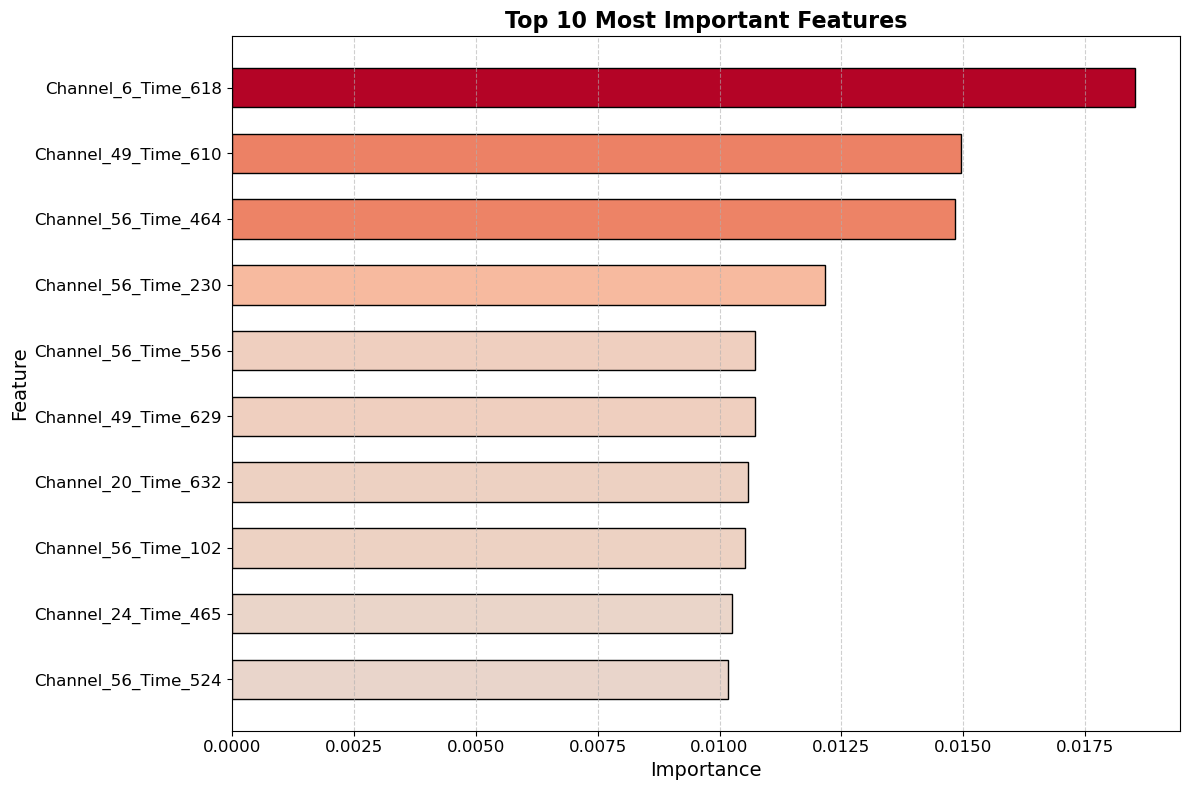

,feature,importance
4824,Channel_6_Time_618,0.018518
34959,Channel_49_Time_610,0.014942
39720,Channel_56_Time_464,0.014831
39486,Channel_56_Time_230,0.012157
39812,Channel_56_Time_556,0.010727
34978,Channel_49_Time_629,0.010723
14652,Channel_20_Time_632,0.010592
39358,Channel_56_Time_102,0.010517
17289,Channel_24_Time_465,0.010266
39780,Channel_56_Time_524,0.010174


In [19]:
# Get feature importance from the trained model
importances = xgb.feature_importances_

# Step 10: Create a DataFrame of feature importances (with channel-timepoint as the feature names)
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Step 11: Visualize the top 10 most important features
top_10_features = feature_importances_df.head(10)

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a color palette based on importance values (from light to dark)
bar_colors = sns.color_palette("coolwarm", as_cmap=True)

# Create the horizontal bar plot
bars = plt.barh(top_10_features['feature'], top_10_features['importance'], 
                color=bar_colors(top_10_features['importance'] / max(top_10_features['importance'])), 
                edgecolor='black', height=0.6)


# Make the title and labels more readable
plt.title('Top 10 Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Invert the y-axis to display the most important feature at the top
plt.gca().invert_yaxis()

# Customize the grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

# Step 12: Optionally, output the top important features for further analysis
top_10_features
